In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler





In [5]:
housing_df = pd.read_csv("house_prices.csv")
housing_df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [6]:
housing_df.columns = housing_df.columns.str.strip()

X = housing_df.drop("house_price_inr", axis=1)
y = housing_df["house_price_inr"]

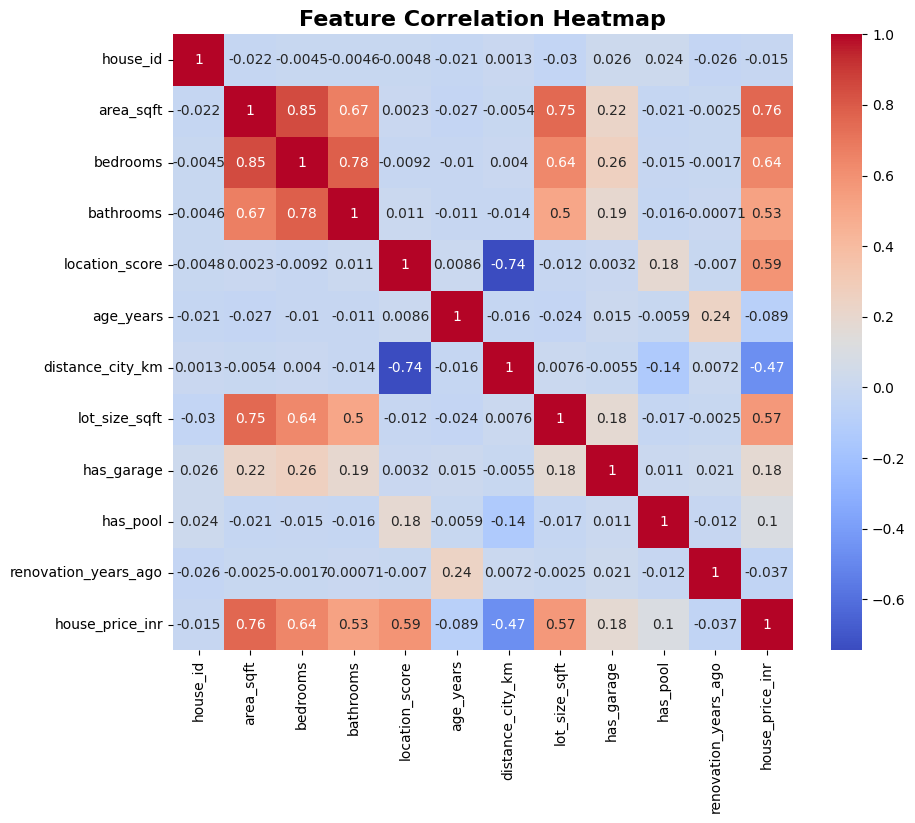

In [44]:
plt.figure(figsize=(10,8))
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm')

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_simple = housing_df[["area_sqft"]]   
y = housing_df["house_price_inr"]

model = LinearRegression()
model.fit(X_train, y_train)
# print(housing_df.columns)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = model.predict(X_test)

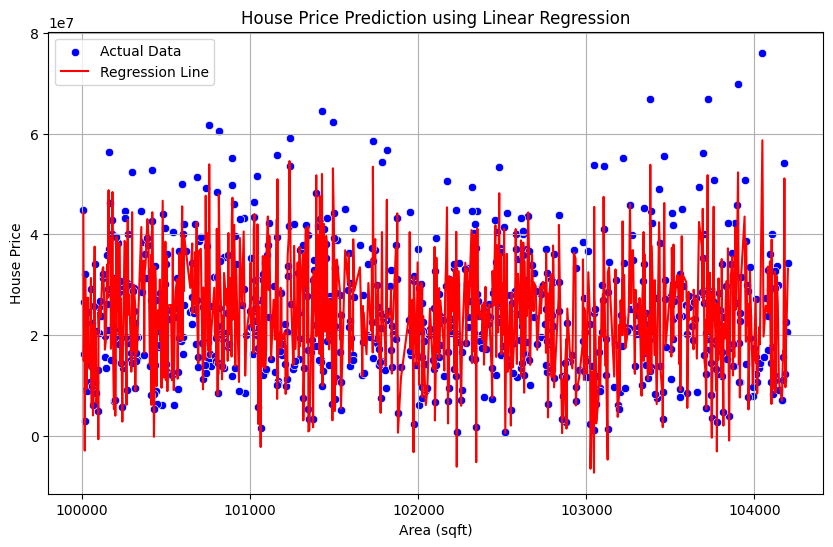

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=X_test.iloc[:,0], y=y_test.values, color='blue', label="Actual Data")

sns.lineplot(x=X_test.iloc[:,0], y=y_pred, color='red', label="Regression Line")

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("House Price Prediction using Linear Regression")

plt.legend()
plt.grid(True)
plt.show()

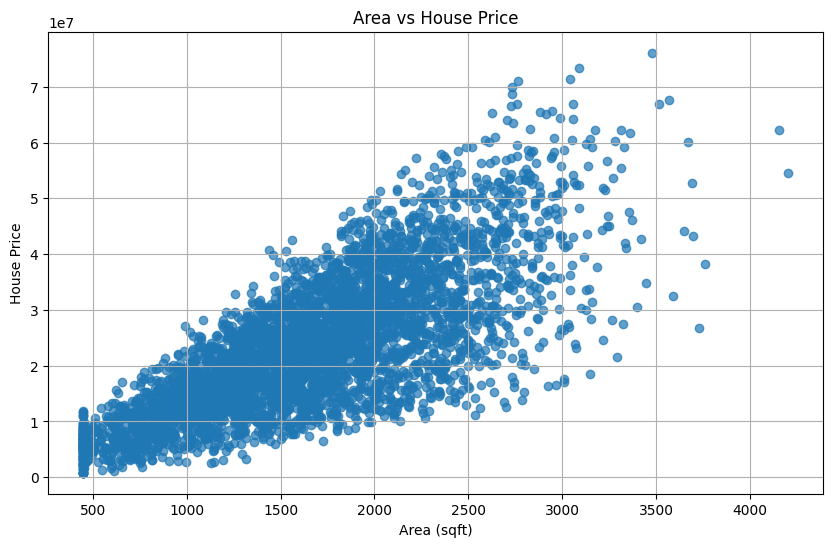

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(housing_df["area_sqft"], housing_df["house_price_inr"], alpha=0.7)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("Area vs House Price")

plt.grid(True)
plt.show()

In [36]:
X = housing_df.drop("house_price_inr", axis=1)

y = housing_df["house_price_inr"]

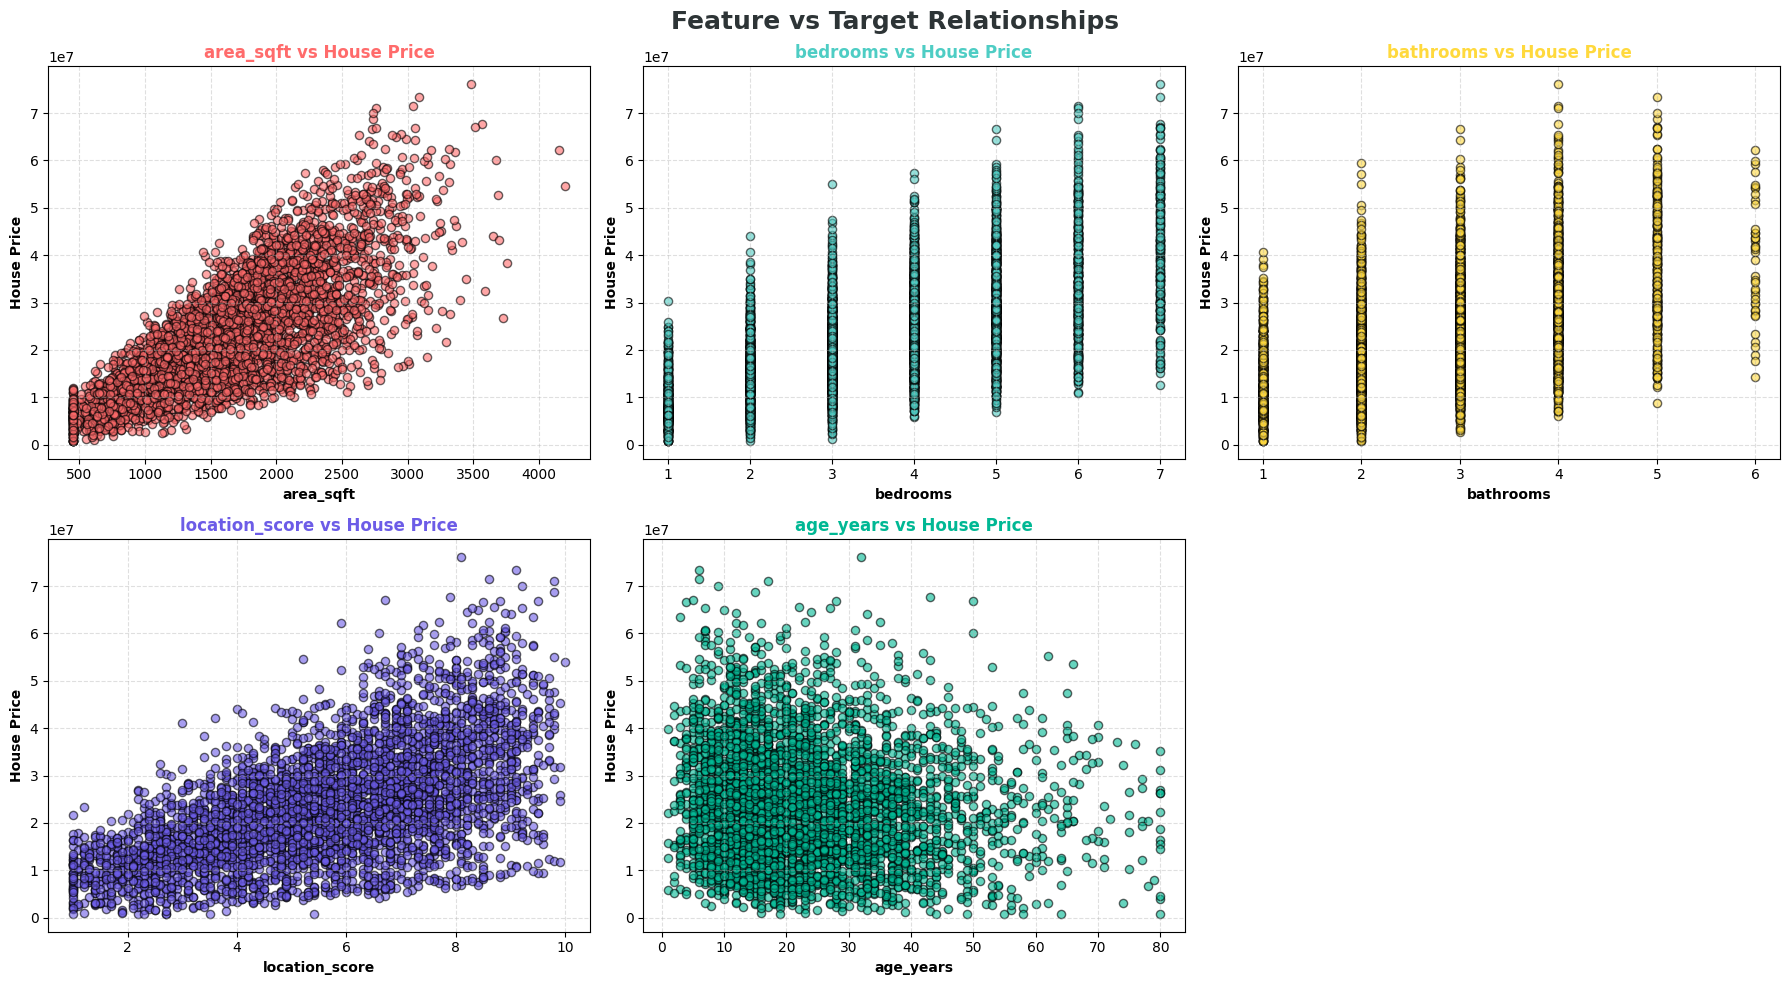

In [ ]:
FEATURES = [
    'area_sqft',
    'bedrooms',
    'bathrooms',
    'location_score',
    'age_years'
]

TARGET = 'house_price_inr'

colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7', '#00B894']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):

    axes[i].scatter(
        housing_df[feat],
        housing_df[TARGET],
        alpha=0.6,
        color=colors[i],
        s=35,
        edgecolor='black'
    )

    axes[i].set_xlabel(
        feat,
        fontsize=10,
        fontweight='bold'
    )

    axes[i].set_ylabel(
        'House Price',
        fontsize=10,
        fontweight='bold'
    )

    axes[i].set_title(
        f'{feat} vs House Price',
        fontsize=12,
        fontweight='bold',
        color=colors[i]
    )

    axes[i].grid(
        True,
        linestyle='--',
        alpha=0.4
    )

fig.delaxes(axes[5])

# Main title
plt.suptitle(
    'Feature vs Target Relationships',
    fontsize=18,
    fontweight='bold',
    color='#2D3436'
)

plt.tight_layout()

plt.savefig(
    'Feature_vs_Target_Colorful.png',
    dpi=150
)

plt.show()

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3360, 11)
Testing Data Shape: (840, 11)


In [13]:
print("Columns:", housing_df.columns.tolist())
print("\nData types:\n", housing_df.dtypes)
print("\nFirst rows:\n", housing_df.head())

Columns: ['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago', 'house_price_inr']

Data types:
 house_id                  int64
area_sqft                 int64
bedrooms                  int64
bathrooms                 int64
location_score          float64
age_years                 int64
distance_city_km        float64
lot_size_sqft             int64
has_garage                int64
has_pool                  int64
renovation_years_ago      int64
house_price_inr           int64
dtype: object

First rows:
    house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    10

In [14]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -11.878983006844111
Intercept: -13551787.595356677


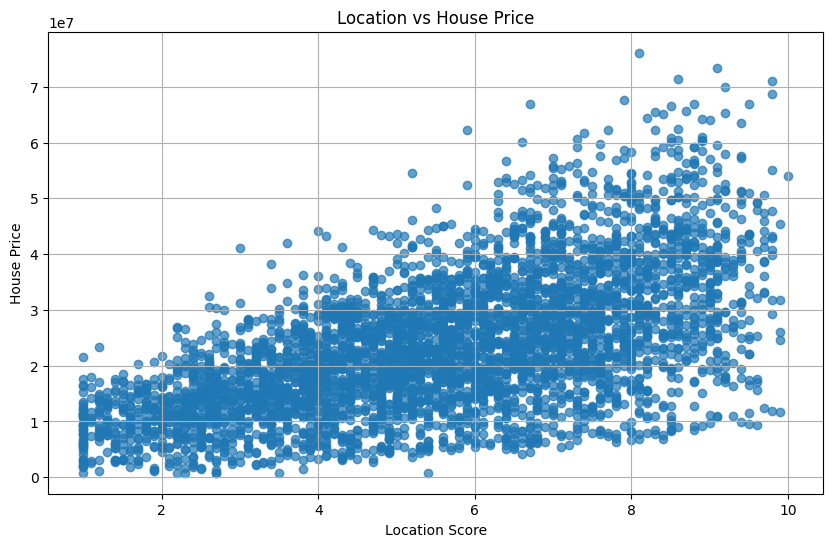

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(housing_df["location_score"], housing_df["house_price_inr"], alpha=0.7)

plt.xlabel("Location Score")
plt.ylabel("House Price")
plt.title("Location vs House Price")

plt.grid(True)
plt.show()

In [16]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R2
n = len(y_test)
p = 1   # number of features (area only)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)

MSE: 12597222158307.7
MAE: 2605648.611505146
RMSE: 3549256.5641705445
R2 Score: 0.9177325847899332
Adjusted R2: 0.9176344136500645


In [17]:
results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE", "R2", "Adjusted R2"],
    "Value": [mse, mae, rmse, r2, adj_r2]
})

print(results)

        Metric         Value
0          MSE  1.259722e+13
1          MAE  2.605649e+06
2         RMSE  3.549257e+06
3           R2  9.177326e-01
4  Adjusted R2  9.176344e-01


In [18]:
X = housing_df.drop("house_price_inr", axis=1)
y = housing_df["house_price_inr"]

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Prediction
y_pred_multi = model_multi.predict(X_test)

In [19]:
print("Multiple Regression R2:", r2_score(y_test, y_pred_multi))

Multiple Regression R2: 0.9177325847899332


In [20]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_train)

model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)

# Prediction
X_test_poly = poly.transform(X_test)
y_pred_poly = model_poly.predict(X_test_poly)

In [ ]:
mse_poly = mean_squared_error(y_test, y_pred_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)

rmse_poly = np.sqrt(mse_poly)

r2_poly = r2_score(y_test, y_pred_poly)

n = len(y_test)               
p = X_test_poly.shape[1] - 1   

adj_r2_poly = 1 - (
    (1 - r2_poly) * (n - 1) / (n - p - 1)
)

print("Polynomial Regression Evaluation Metrics\n")

print("MSE :", mse_poly)

print("MAE :", mae_poly)

print("RMSE :", rmse_poly)

print("R2 Score :", r2_poly)

print("Adjusted R2 Score :", adj_r2_poly)

Polynomial Regression Evaluation Metrics

MSE : 5119996328508.131
MAE : 1659159.3191754783
RMSE : 2262740.888504057
R2 Score : 0.9665633535284115
Adjusted R2 Score : 0.9631845847904689


In [21]:
print("Polynomial R2:", r2_score(y_test, y_pred_poly))

Polynomial R2: 0.9665633535284115


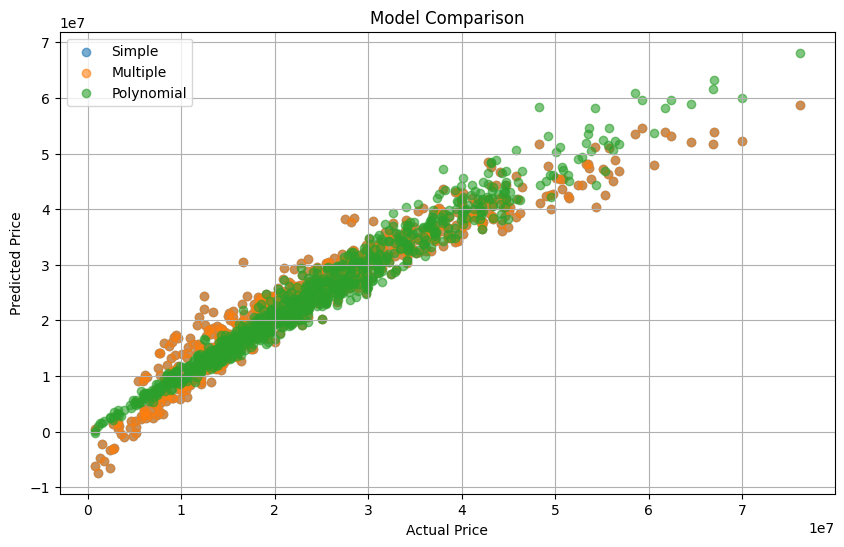

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred, label="Simple", alpha=0.6)
plt.scatter(y_test, y_pred_multi, label="Multiple", alpha=0.6)
plt.scatter(y_test, y_pred_poly, label="Polynomial", alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Model Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
X = housing_df.drop("house_price_inr", axis=1)
y = housing_df["house_price_inr"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert y
y_scaled = y.values.reshape(-1,1) / 1000000

# Add bias term
X_b = np.c_[np.ones((len(X_scaled),1)), X_scaled]

In [26]:
def batch_gradient_descent(X, y, lr=0.01, epochs=1000):

    m, n = X.shape
    theta = np.zeros((n,1))

    losses = []

    for epoch in range(epochs):

        predictions = X.dot(theta)

        gradients = (2/m) * X.T.dot(predictions - y)

        theta = theta - lr * gradients

        loss = np.mean((predictions - y) ** 2)

        losses.append(loss)

    return theta, losses

In [27]:
theta_batch, loss_batch = batch_gradient_descent(X_b, y_scaled)

print("Batch GD Theta:")
print(theta_batch)

Batch GD Theta:
[[ 2.36418864e+01]
 [ 1.37780688e-02]
 [ 8.40858962e+00]
 [ 6.55410870e-01]
 [ 1.10970934e-01]
 [ 6.64288700e+00]
 [-8.98376595e-01]
 [-8.33470019e-01]
 [ 2.94752111e-01]
 [ 5.81120878e-02]
 [ 1.16454383e-01]
 [-1.72436081e-01]]


In [28]:
def stochastic_gradient_descent(X, y, lr=0.01, epochs=50):

    m, n = X.shape
    theta = np.zeros((n,1))

    losses = []

    for epoch in range(epochs):

        for i in range(m):

            xi = X[i:i+1]
            yi = y[i:i+1]

            prediction = xi.dot(theta)

            gradients = 2 * xi.T.dot(prediction - yi)

            theta = theta - lr * gradients

        loss = np.mean((X.dot(theta) - y) ** 2)

        losses.append(loss)

    return theta, losses

In [29]:
theta_sgd, loss_sgd = stochastic_gradient_descent(X_b, y_scaled)

print("SGD Theta:")
print(theta_sgd)

SGD Theta:
[[23.62346547]
 [ 0.83185179]
 [ 9.84698229]
 [ 0.65888438]
 [ 1.0474976 ]
 [ 6.80567605]
 [-1.44634683]
 [-1.30230571]
 [ 0.57508848]
 [ 0.50804947]
 [ 0.18290958]
 [-0.60817987]]


In [30]:
def mini_batch_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=32):

    m, n = X.shape
    theta = np.zeros((n,1))

    losses = []

    for epoch in range(epochs):

        for i in range(0, m, batch_size):

            xi = X[i:i+batch_size]
            yi = y[i:i+batch_size]

            predictions = xi.dot(theta)

            gradients = (2/len(xi)) * xi.T.dot(predictions - yi)

            theta = theta - lr * gradients

        loss = np.mean((X.dot(theta) - y) ** 2)

        losses.append(loss)

    return theta, losses

In [31]:
theta_mini, loss_mini = mini_batch_gradient_descent(X_b, y_scaled)

print("Mini-Batch Theta:")
print(theta_mini)

Mini-Batch Theta:
[[23.64451377]
 [ 0.09608178]
 [ 8.95358582]
 [ 0.4796277 ]
 [ 0.28524789]
 [ 6.6926353 ]
 [-0.96490531]
 [-0.85307639]
 [ 0.2611541 ]
 [ 0.07425703]
 [ 0.10141434]
 [-0.23272525]]


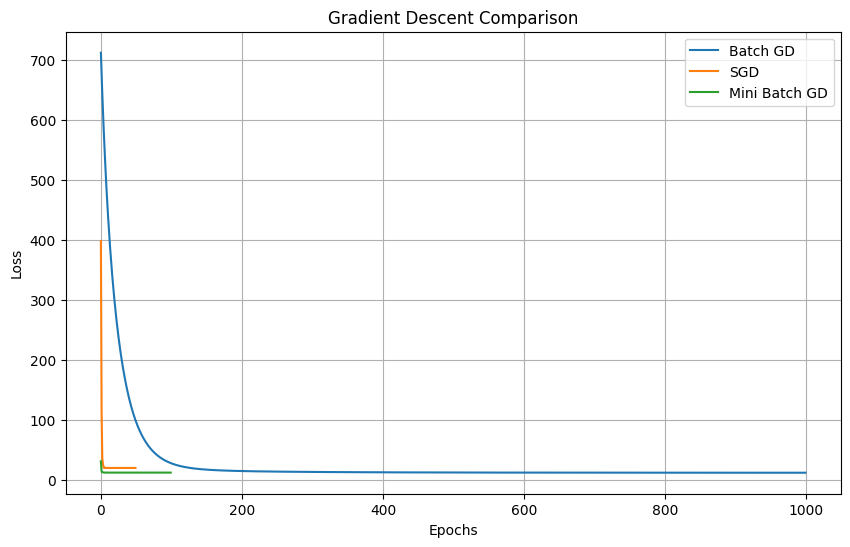

In [34]:

plt.figure(figsize=(10,6))

plt.plot(loss_batch, label="Batch GD")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mini, label="Mini Batch GD")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Gradient Descent Comparison")

plt.legend()
plt.grid(True)

plt.show()

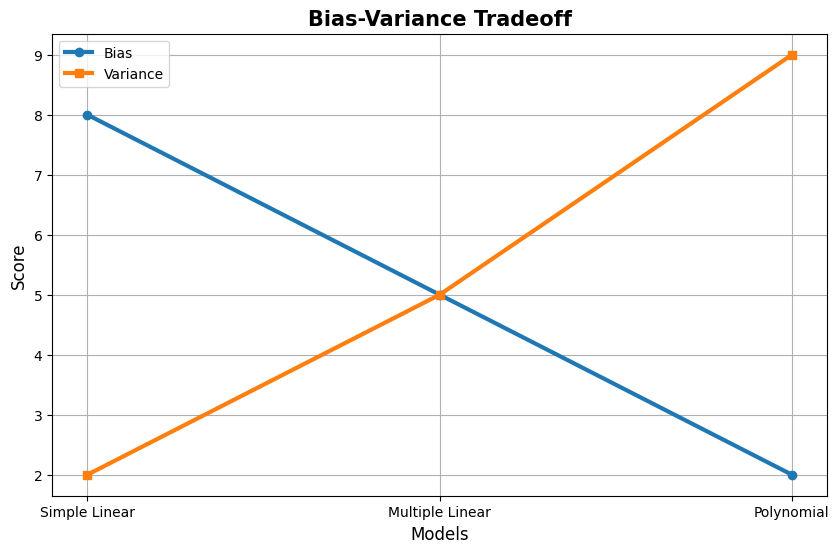

In [41]:

models = [
    'Simple Linear',
    'Multiple Linear',
    'Polynomial'
]

bias = [8, 5, 2]
variance = [2, 5, 9]

plt.figure(figsize=(10,6))

plt.plot(
    models,
    bias,
    marker='o',
    linewidth=3,
    label='Bias'
)

plt.plot(
    models,
    variance,
    marker='s',
    linewidth=3,
    label='Variance'
)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)

plt.title(
    'Bias-Variance Tradeoff',
    fontsize=15,
    fontweight='bold'
)

plt.legend()
plt.grid(True)

plt.show()